# TITLE:
 * #  Machine Learning Classification using Adult Census Income Dataset

# OBJECTIVE:
The main objective is to build machine learning classification models to predict whether an individual's annual income exceeds $50K based on demographic and employment-related features. I have used three different classifiers :(i.e. Support Vector Machine, k-Nearest Neighbors, and Decision Tree) and are trained and compared using various evaluation metrics.

# Step1:  Importing Dataset

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/adult-census-income")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/organizations/uciml/adult-census-income


In [4]:
import os
data_file=os.path.join(path,"adult.csv")
df= pd.read_csv(data_file)


# Step2:  Importing Neccessary Libraries: 

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.model_selection import GridSearchCV

In [9]:
df.head()
# It shows first five records

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


# Step 3: Exploring dataset

In [10]:
df.shape
# It shows the number of rows and columns in the dataset

(32561, 15)

In [11]:
df.info()
# It displays the data types and missing values.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [12]:
df.describe()
# It provides summary statistics for numerical features

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


**Step 4: Checking Missing Values:**

In [14]:
(df == "?").sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

*Here, multiple missing values are found in workclass, occupation and native.country*

**Step 5: Checking Duplicated Rows**

In [15]:
df.duplicated().sum()

np.int64(24)

# Step 6: Visual Analysis:

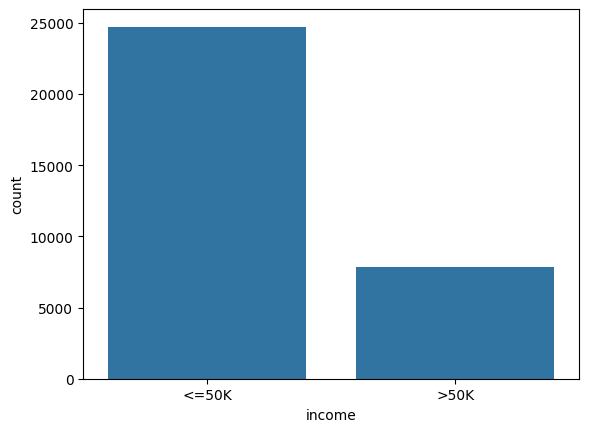

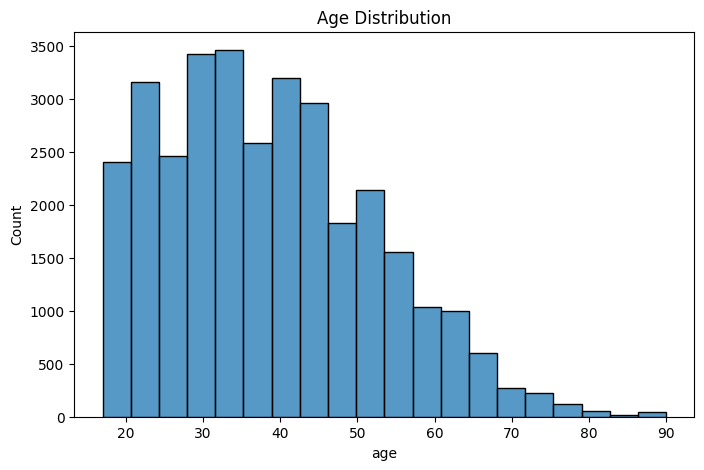

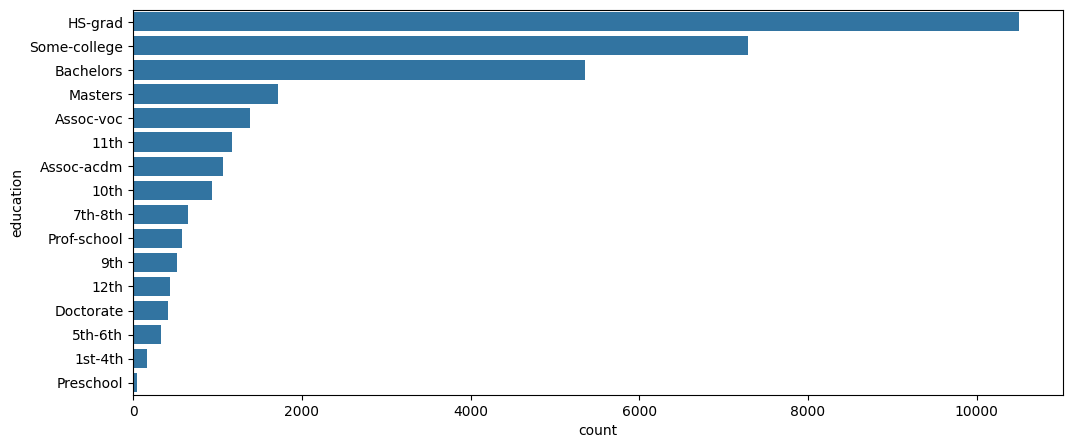

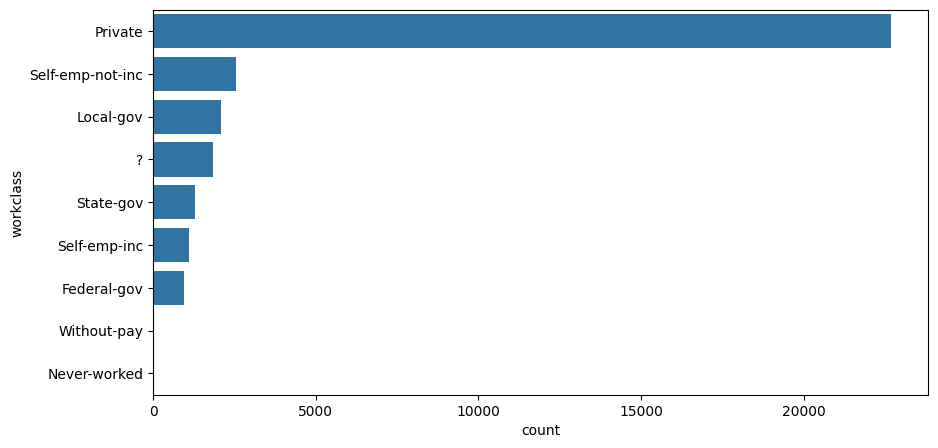

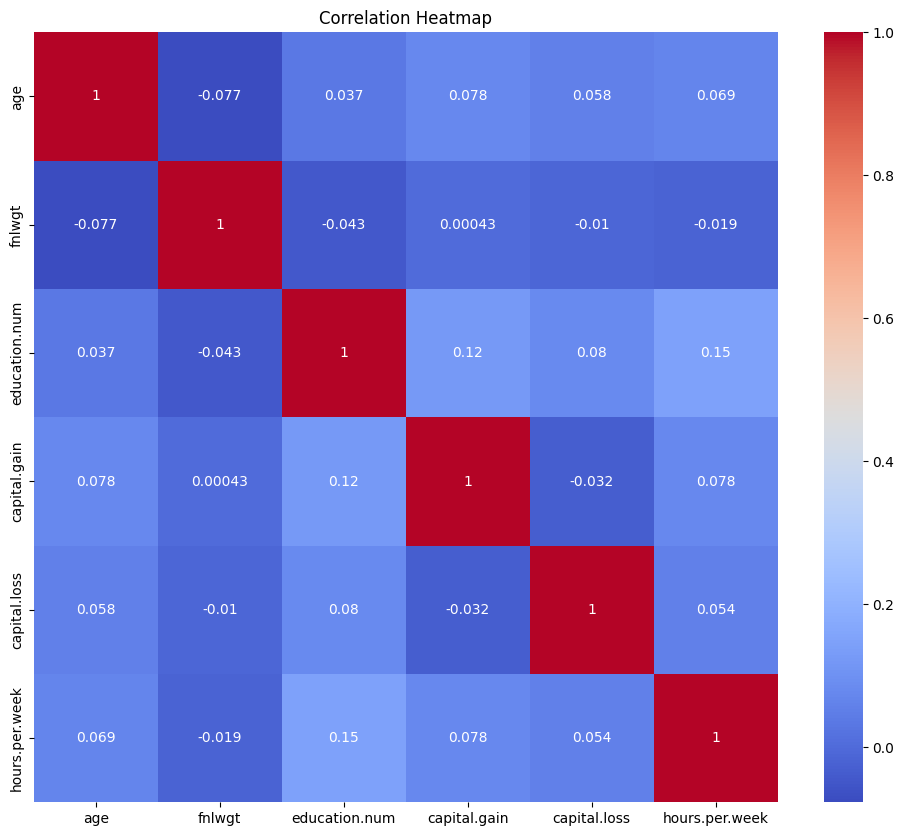

In [7]:
# 6.1 Income Distribution
sns.countplot(x='income', data=df)

# 6.2 Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20)
plt.title("Age Distribution")

#6.3 Education Distribution
plt.figure(figsize=(12,5))
sns.countplot(
    y='education',
    data=df,
    order=df['education'].value_counts().index
)

#6.4 Workclass Distribution
plt.figure(figsize=(10,5))
sns.countplot(
    y='workclass',
    data=df,
    order=df['workclass'].value_counts().index
)
#6.5 Correlation Heatmap


plt.figure(figsize=(12,10))

# Selecting only numerical columns
numeric_df = df.select_dtypes(include=np.number)

# Plot correlation heatmap
sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm',
    annot=True
)

plt.title("Correlation Heatmap")
plt.show()


# Step7: Data Preprocessing :

# 7.1. Handling Missing values

In [17]:
df.replace("?", np.nan, inplace=True)

df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

# 7.1.1 Removing Missing Values:

In [19]:
df.dropna(inplace=True)

In [21]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

> Hence, no missing records found. Missing values reduce model quality. Rows containing missing values were removed because they represented only a small portion of the dataset.

# 7.2: Removing Duplicates


In [63]:
before = df.shape[0]

df.drop_duplicates(inplace=True)

after = df.shape[0]

print("Duplicates removed:", before - after)

# Duplicate records were removed because repeated samples can bias the learning process and affect model performance

Duplicates removed: 24


# 7.3: Encoding Categorical Variables


In [64]:
le = LabelEncoder()

df['income'] = le.fit_transform(df['income'])
#Explanation:
#The target variable (income) was converted into numerical form using Label Encoding. 
#The categorical input features were transformed using One-Hot Encoding so that machine learning algorithms could process them.

#  7.4: Separation of Features and Target variables


In [65]:
X = df.drop("income", axis=1)
y = df["income"]

X = pd.get_dummies(X, drop_first=True)
X = X.astype(int)

# Here, the dataset is divided into input features (X) and the target variable (y)

# 7.5: Encoding Categorical Data

In [67]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['income'] = le.fit_transform(df['income'])
print(df['income'].unique())

[0 1]


# Step 8: Test-Train Split:



In [84]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



# Here, the dataset is split into training and testing sets. Stratification preserves the class distribution in both sets.
# 80% test and 20% train

# Step 9: Feature Scaling


In [77]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)



# Standardization scales numerical features to a similar range, which improves the performance of distance-based algorithms like SVM and kNN.

# Step 10: Defining Models;

# 10.1 SVM Model

In [90]:
svm_pred = svm.predict(X_test_scaled)


In [78]:

svm = SVC()

svm.fit(X_train_scaled, y_train)



# The SVM classifier is trained to find the optimal boundary that separates the two income classes.

SVC()

# 10.2 kNN Model

In [ ]:

knn_pred = knn.predict(X_test_scaled)



In [79]:

knn = KNeighborsClassifier()

knn.fit(X_train_scaled, y_train)


# The kNN classifier predicts the class based on the majority class of the nearest neighboring samples.

KNeighborsClassifier()

# 10.3 Decision Tree

In [ ]:
dt_pred = dt.predict(X_test)

In [80]:

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)


# The Decision Tree learns a set of decision rules from the training data to classify income levels.

DecisionTreeClassifier(random_state=42)

# Step 11: Prediction:

In [91]:
svm.fit(X_train_scaled, y_train)

knn.fit(X_train_scaled, y_train)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [74]:
print(y_test[:5])
print(svm_pred[:5])

21111    0
21478    1
20824    0
22147    0
11438    0
Name: income, dtype: int64
[0 0 1 1 0]


# Step 12: Model Comparison

In [89]:
results = pd.DataFrame([
    {
        "Model":"SVM",
        "Accuracy":accuracy_score(y_test, svm_pred),
        "Precision":precision_score(y_test, svm_pred),
        "Recall":recall_score(y_test, svm_pred),
        "F1 Score":f1_score(y_test, svm_pred)
    },
    {
        "Model":"kNN",
        "Accuracy":accuracy_score(y_test, knn_pred),
        "Precision":precision_score(y_test, knn_pred),
        "Recall":recall_score(y_test, knn_pred),
        "F1 Score":f1_score(y_test, knn_pred)
    },
    {
        "Model":"Decision Tree",
        "Accuracy":accuracy_score(y_test, dt_pred),
        "Precision":precision_score(y_test, dt_pred),
        "Recall":recall_score(y_test, dt_pred),
        "F1 Score":f1_score(y_test, dt_pred)
    }
])

results

,Model,Accuracy,Precision,Recall,F1 Score
0,SVM,0.843884,0.738754,0.544643,0.627019
1,kNN,0.816687,0.639198,0.549107,0.590738
2,Decision Tree,0.811616,0.606343,0.621811,0.613980


# Step:13 Evaluation:

In [92]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, svm_pred)
precision = precision_score(y_test, svm_pred)
recall = recall_score(y_test, svm_pred)
f1 = f1_score(y_test, svm_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.8438844499078058
Precision: 0.7387543252595156
Recall: 0.5446428571428571
F1 Score: 0.6270190895741556


* From above, the SVM classifier achieved an accuracy of 84.38%. The precision of 73.87% indicates that most positive predictions were correct, while the recall of 54.46% shows that the model was able to identify more than half of the actual positive cases. The F1-score of 62.70% represents a balance between precision and recall. Although the model provides good overall accuracy, improving recall could help in better identifying high-income individuals.*

# Step 14: Confusion Matrix

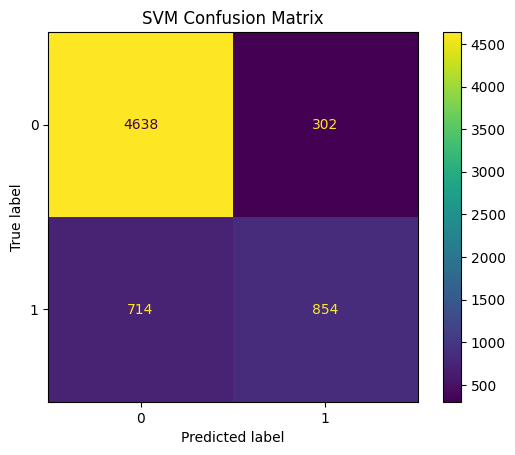

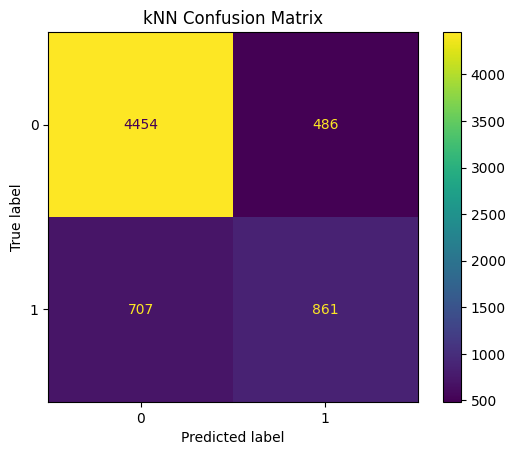

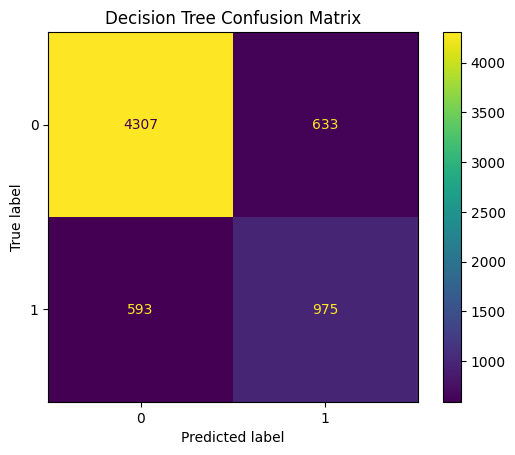

In [93]:
from sklearn.metrics import ConfusionMatrixDisplay


ConfusionMatrixDisplay.from_predictions(
    y_test,
    svm_pred
)

plt.title("SVM Confusion Matrix")
plt.show()


ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn_pred
)

plt.title("kNN Confusion Matrix")
plt.show()


ConfusionMatrixDisplay.from_predictions(
    y_test,
    dt_pred
)

plt.title("Decision Tree Confusion Matrix")
plt.show()

In [42]:
print(X_train.shape)
print(X_test.shape)

(26048, 100)
(6513, 100)


# Step:15 HyperParameter Tuning

In [96]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Defining parameters to test
param_grid = {
    'C': [1, 10],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

# Creating GridSearchCV
grid_search = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy'
)

# Train and search for best parameters
grid_search.fit(X_train_scaled, y_train)

# Displaying best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation Accuracy:", grid_search.best_score_)

Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best Cross Validation Accuracy: 0.8484768107904964


# Comparsion for best model: 

In [100]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(name, y_true, y_pred):
    print(name)
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))


best_svm = grid_search.best_estimator_

svm_tuned_pred = best_svm.predict(X_test_scaled)

evaluate_model("Tuned SVM", y_test, svm_tuned_pred)

Tuned SVM
Accuracy: 0.8438844499078058
Precision: 0.7387543252595156
Recall: 0.5446428571428571
F1 Score: 0.6270190895741556


*Overview:
The tuned kNN classifier achieved an accuracy of 84.38%. The precision of 73.87% indicates that most positive predictions were correct, while the recall of 54.46% shows that the model identified more than half of the actual high-income individuals. The F1-score of 62.70% represents the balance between precision and recall. Compared with accuracy, the lower recall indicates that the model still struggles to identify some high-income cases due to class imbalance in the dataset.*

# Comparison Before and After

In [101]:
svm_before = {
    "Model":"SVM Before Tuning",
    "Accuracy":accuracy_score(y_test, svm_pred),
    "Precision":precision_score(y_test, svm_pred),
    "Recall":recall_score(y_test, svm_pred),
    "F1 Score":f1_score(y_test, svm_pred)
}


In [103]:
svm_after = {
    "Model":"SVM After Tuning",
    "Accuracy":accuracy_score(y_test, svm_tuned_pred),
    "Precision":precision_score(y_test, svm_tuned_pred),
    "Recall":recall_score(y_test, svm_tuned_pred),
    "F1 Score":f1_score(y_test, svm_tuned_pred)
}


*Creating Comparion table:*

In [104]:
pd.DataFrame([
    svm_before,
    svm_after
])

,Model,Accuracy,Precision,Recall,F1 Score
0,SVM Before Tuning,0.843884,0.738754,0.544643,0.627019
1,SVM After Tuning,0.843884,0.738754,0.544643,0.627019


*Explanation: Hyperparameter tuning did not produce significant improvement because GridSearch selected the same parameters as the default SVM model. This indicates that the default SVM configuration was already suitable for this dataset.*

# Final Model Comparison Table

In [106]:
final_results = pd.DataFrame([
    {
        "Model":"SVM",
        "Accuracy":accuracy_score(y_test, svm_pred),
        "Precision":precision_score(y_test, svm_pred),
        "Recall":recall_score(y_test, svm_pred),
        "F1 Score":f1_score(y_test, svm_pred)
    },
    {
        "Model":"kNN",
        "Accuracy":accuracy_score(y_test, knn_pred),
        "Precision":precision_score(y_test, knn_pred),
        "Recall":recall_score(y_test, knn_pred),
        "F1 Score":f1_score(y_test, knn_pred)
    },
    {
        "Model":"Decision Tree",
        "Accuracy":accuracy_score(y_test, dt_pred),
        "Precision":precision_score(y_test, dt_pred),
        "Recall":recall_score(y_test, dt_pred),
        "F1 Score":f1_score(y_test, dt_pred)
    },
    {
        "Model":"Tuned SVM",
        "Accuracy":accuracy_score(y_test, svm_tuned_pred),
        "Precision":precision_score(y_test, svm_tuned_pred),
        "Recall":recall_score(y_test, svm_tuned_pred),
        "F1 Score":f1_score(y_test, svm_tuned_pred)
    }
])

final_results

,Model,Accuracy,Precision,Recall,F1 Score
0,SVM,0.843884,0.738754,0.544643,0.627019
1,kNN,0.816687,0.639198,0.549107,0.590738
2,Decision Tree,0.811616,0.606343,0.621811,0.613980
3,Tuned SVM,0.843884,0.738754,0.544643,0.627019


## Conclusion

In this project, three classification algorithms, Support Vector Machine (SVM), k-Nearest Neighbors (kNN), and Decision Tree, were implemented to predict whether an individual's income exceeds $50K using the Adult Census Income dataset.

Among the three models, SVM achieved the highest overall performance with the highest accuracy and F1-score. This indicates that SVM was able to better separate the two income classes by finding an effective decision boundary in the feature space.

The kNN classifier achieved lower performance because it relies on distance calculations between samples. Since the dataset contains many features after one-hot encoding, the distance between samples becomes less meaningful in high-dimensional space.

The Decision Tree model achieved a higher recall compared to some other models, meaning it was better at identifying high-income individuals. However, its lower accuracy suggests that it may have learned some patterns specific to the training data and may suffer from overfitting.

Hyperparameter tuning was performed on the SVM classifier using GridSearchCV. The tuning process selected the best parameter combination, but the performance remained similar to the default SVM model. This shows that the original SVM parameters were already suitable for this dataset.

Overall, SVM was selected as the best-performing model for this classification task because it provided the best balance between accuracy, precision, recall, and F1-score.